📊 Running All 6 Regression Models...

[Pitcher Fastball Velocity Regression Stats]
  * Equation: y = -0.0016x^2 + -0.0970x + 98.3004
  * R-squared: 0.0520
  * Standard Error: 2.4233
  * Sample Size (N): 880

[Pitcher Fastball Spin Rate Regression Stats]
  * Equation: y = -0.2298x^2 + 15.3565x + 2019.0626
  * R-squared: 0.0003
  * Standard Error: 158.1079
  * Sample Size (N): 880

[Pitcher Chase Rate (Induction) Regression Stats]
  * Equation: y = -0.0003x^2 + 0.0168x + 0.0250
  * R-squared: 0.0071
  * Standard Error: 0.0358
  * Sample Size (N): 919

[Hitter Exit Velocity Regression Stats]
  * Equation: y = -0.0059x^2 + 0.4112x + 75.4628
  * R-squared: 0.0034
  * Standard Error: 1.7302
  * Sample Size (N): 642

[Hitter Batting Average (Contact) Regression Stats]
  * Equation: y = -0.0000x^2 + 0.0009x + 0.0466
  * R-squared: 0.0042
  * Standard Error: 0.0092
  * Sample Size (N): 642

[Hitter Chase Rate (Discipline) Regression Stats]
  * Equation: y = 0.0001x^2 + -0.0049x + 0.3607
  * R-s

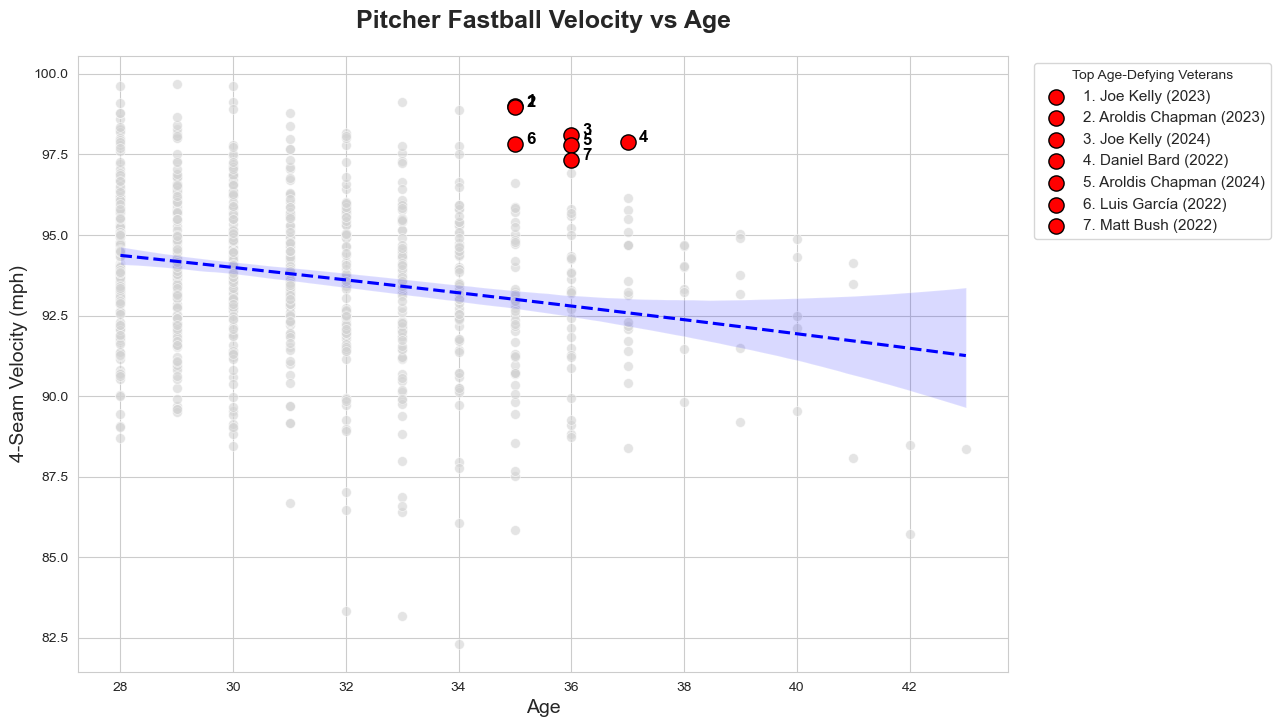

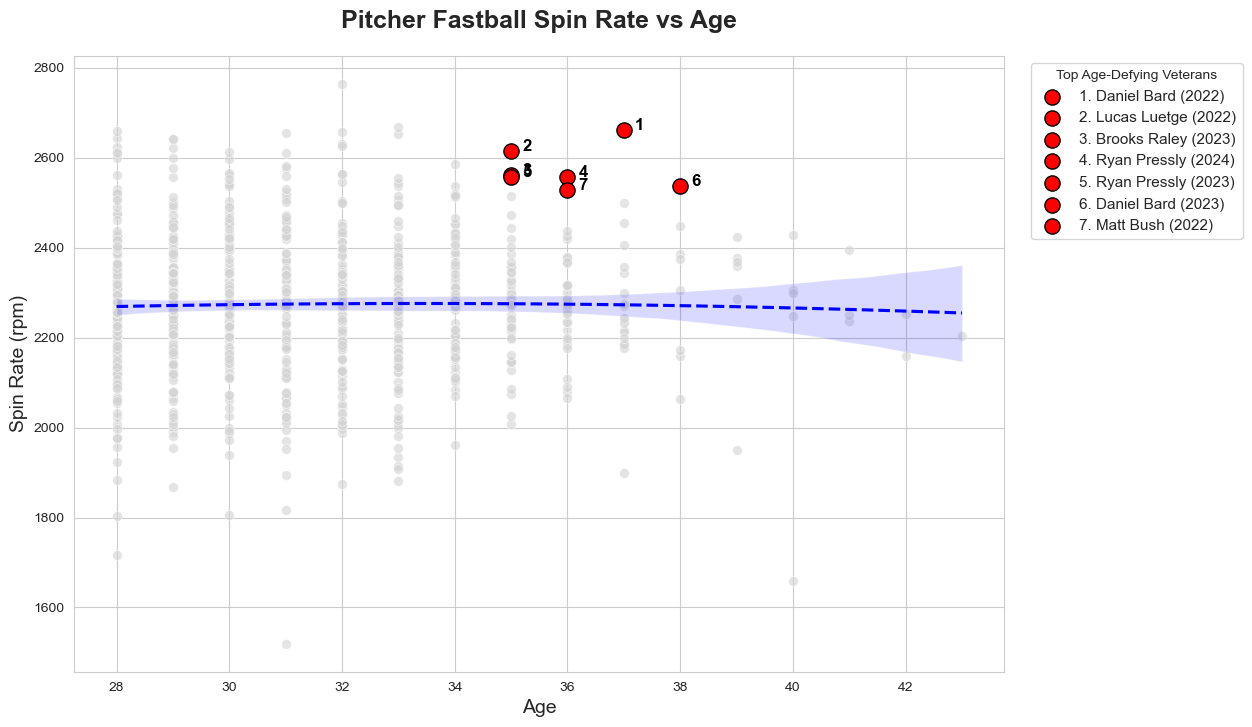

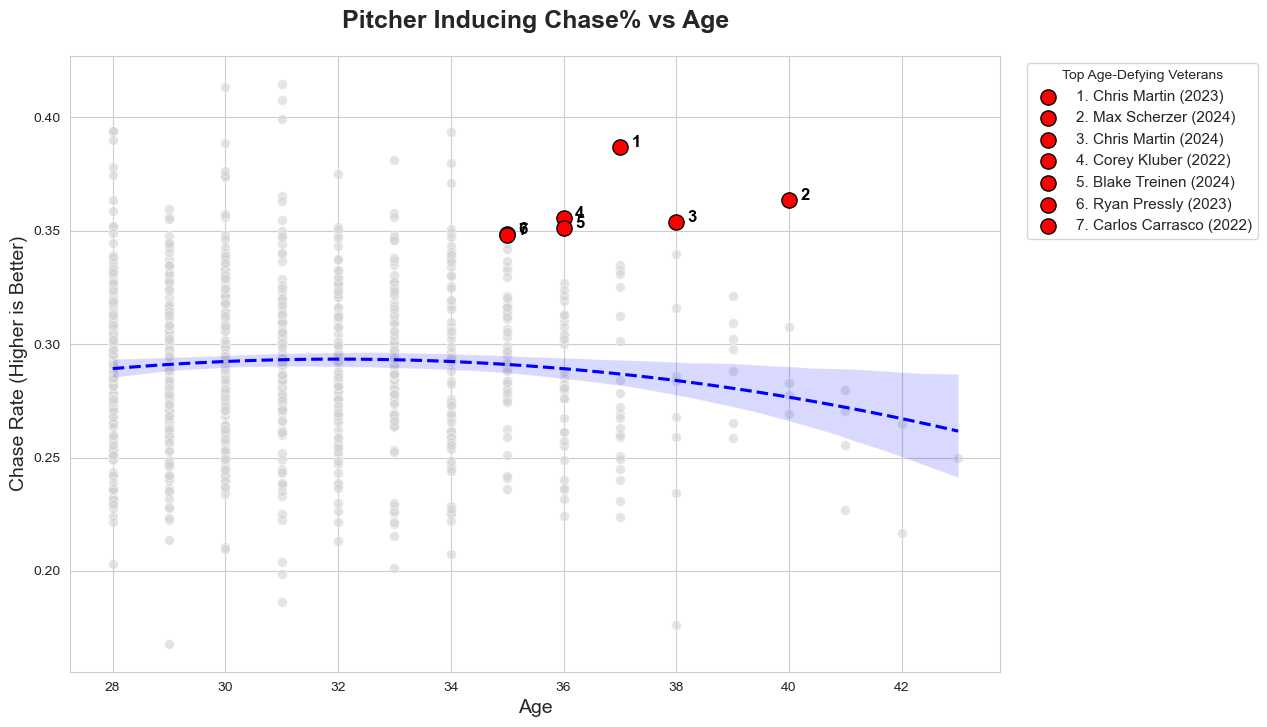

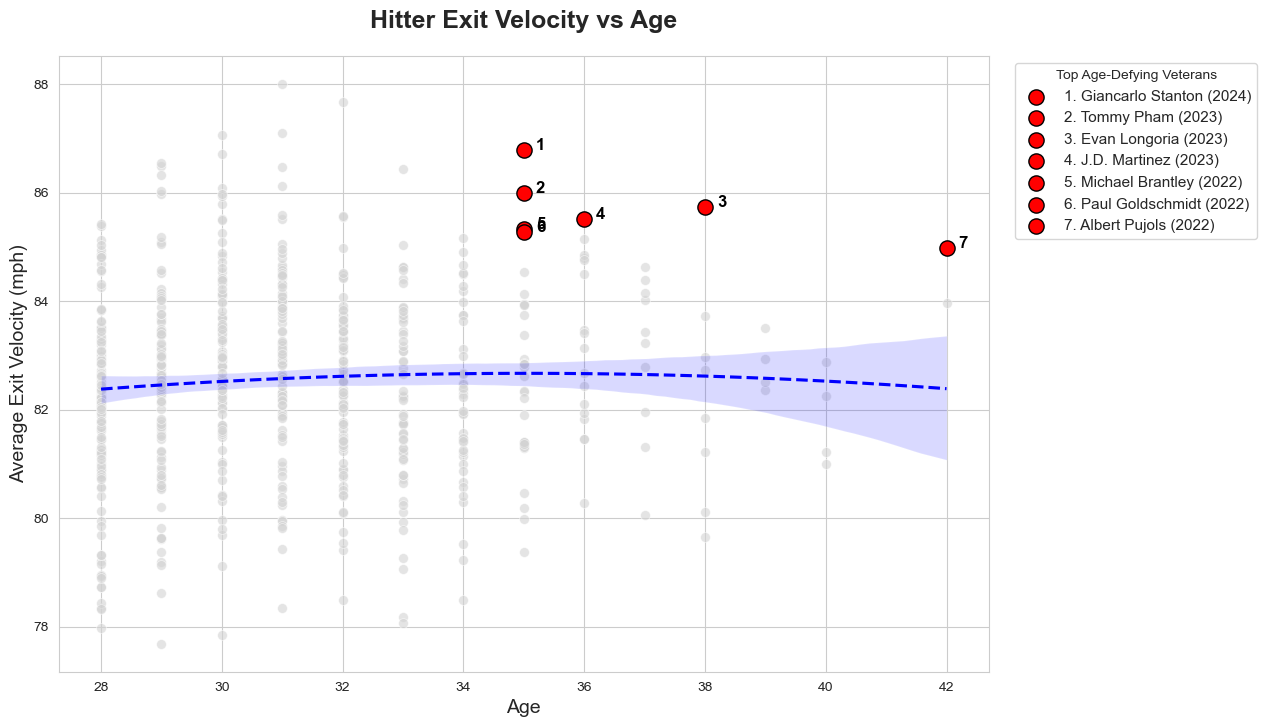

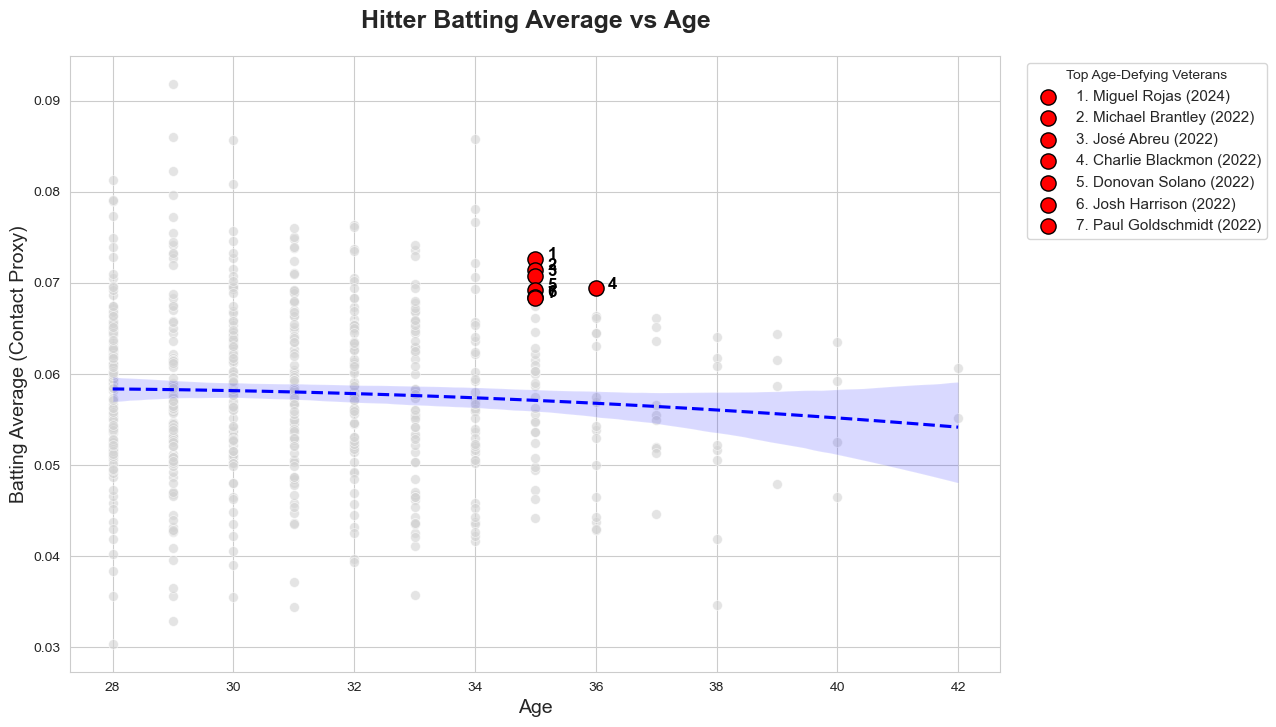

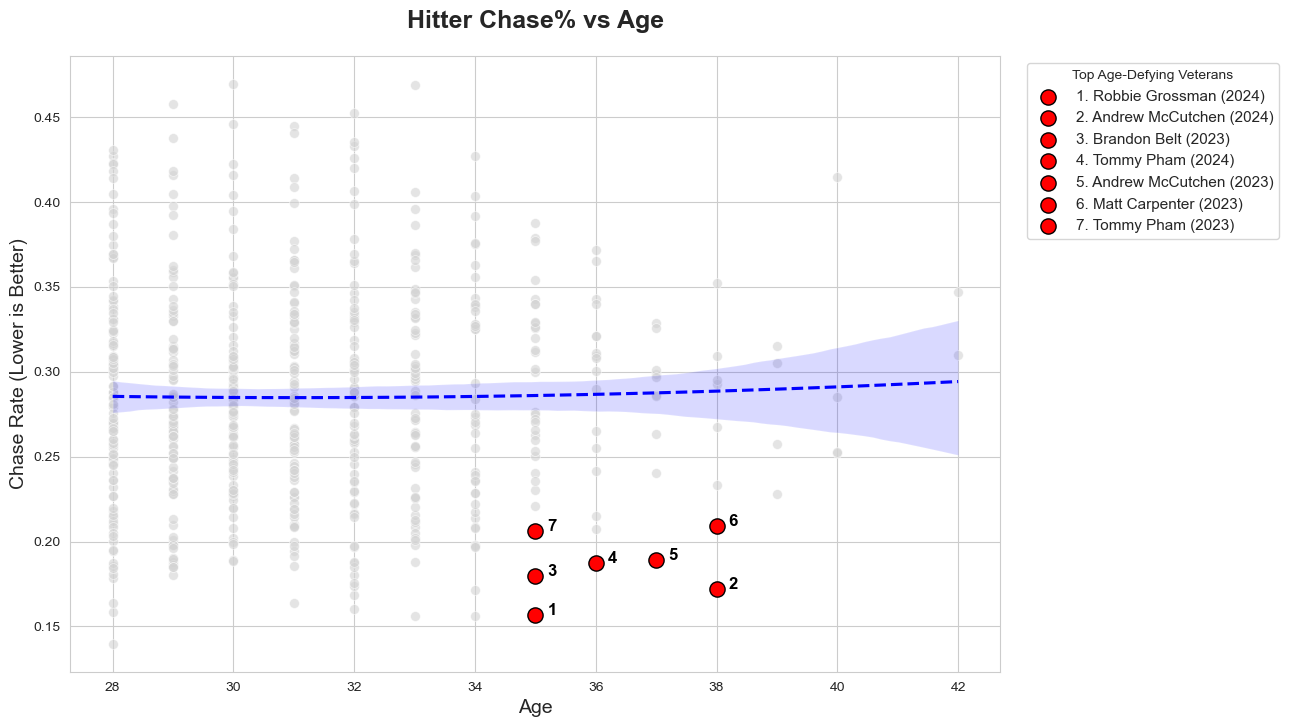


🎯 [복사해서 03번 파일에 넣을 딕셔너리]
target_hitters_dict = {
    'Giancarlo Stanton': 'Exit Velocity',
    'Tommy Pham': 'Exit Velocity',
    'Evan Longoria': 'Exit Velocity',
    'J.D. Martinez': 'Exit Velocity',
    'Michael Brantley': 'Exit Velocity',
    'Paul Goldschmidt': 'Exit Velocity',
    'Albert Pujols': 'Exit Velocity',
    'Yasmani Grandal': 'Exit Velocity',
    'Paul Goldschmidt': 'Exit Velocity',
    'Carlos Santana': 'Exit Velocity',
    'DJ LeMahieu': 'Exit Velocity',
    'Paul Goldschmidt': 'Exit Velocity',
    'José Abreu': 'Exit Velocity',
    'Tommy Pham': 'Exit Velocity',
    'Evan Longoria': 'Exit Velocity',
    'Robbie Grossman': 'Chase% (Discipline)',
    'Andrew McCutchen': 'Chase% (Discipline)',
    'Brandon Belt': 'Chase% (Discipline)',
    'Tommy Pham': 'Chase% (Discipline)',
    'Andrew McCutchen': 'Chase% (Discipline)',
    'Matt Carpenter': 'Chase% (Discipline)',
    'Tommy Pham': 'Chase% (Discipline)',
    'Andrew McCutchen': 'Chase% (Discipline)',
    'Carlos San

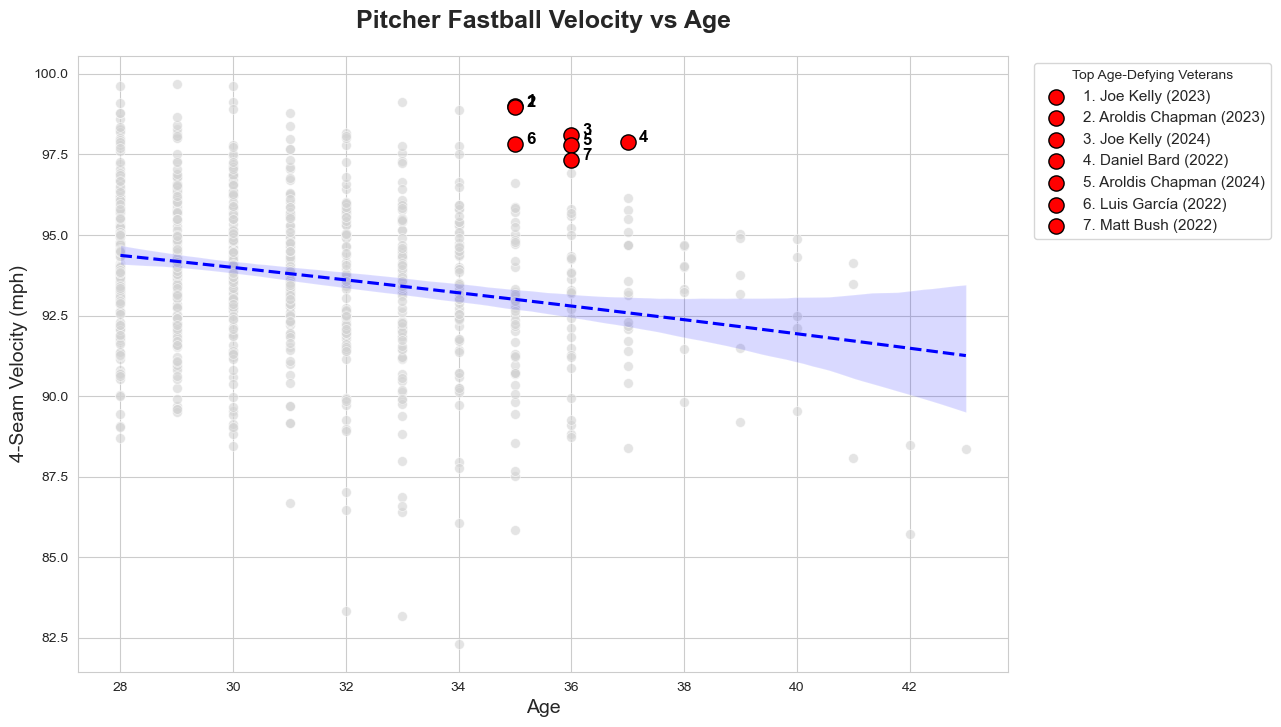

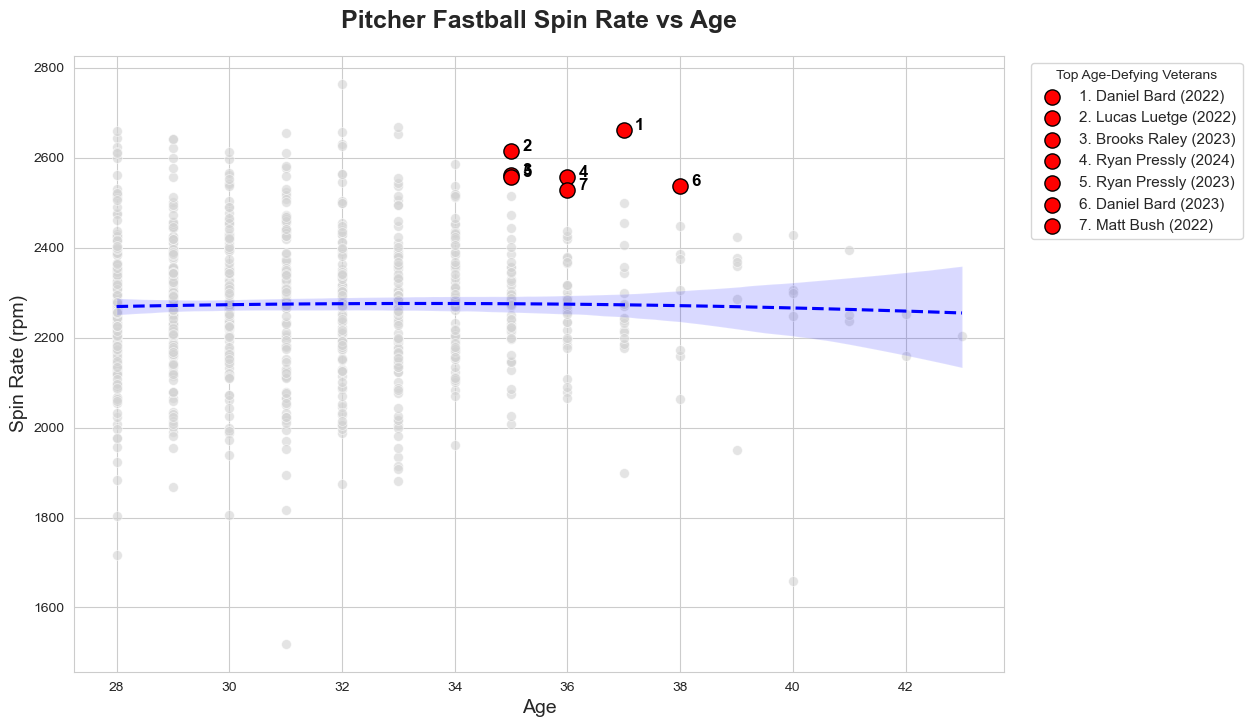

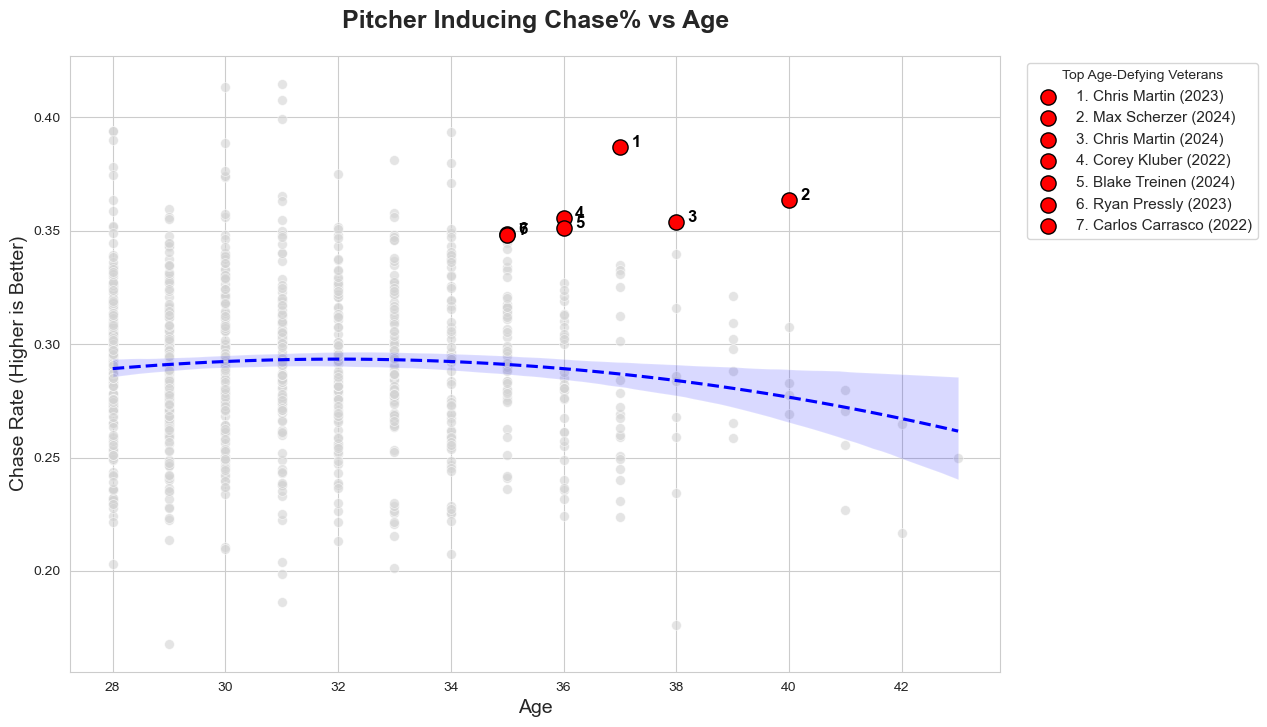

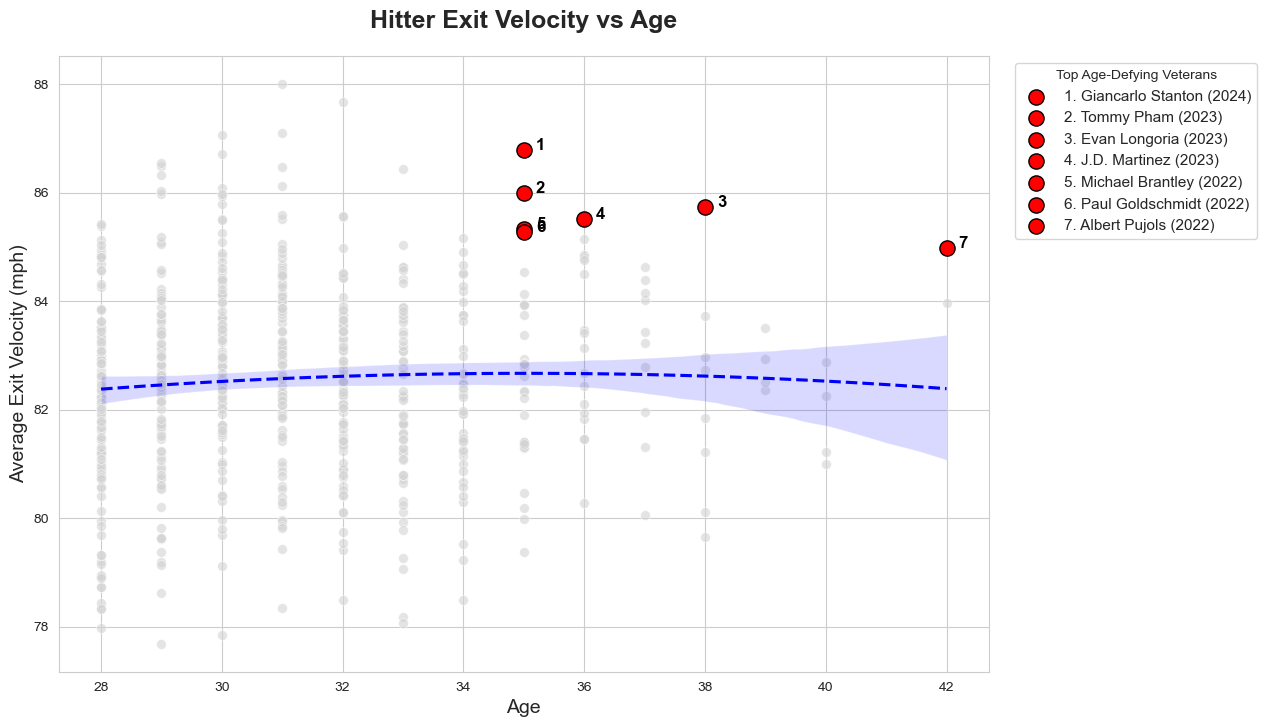

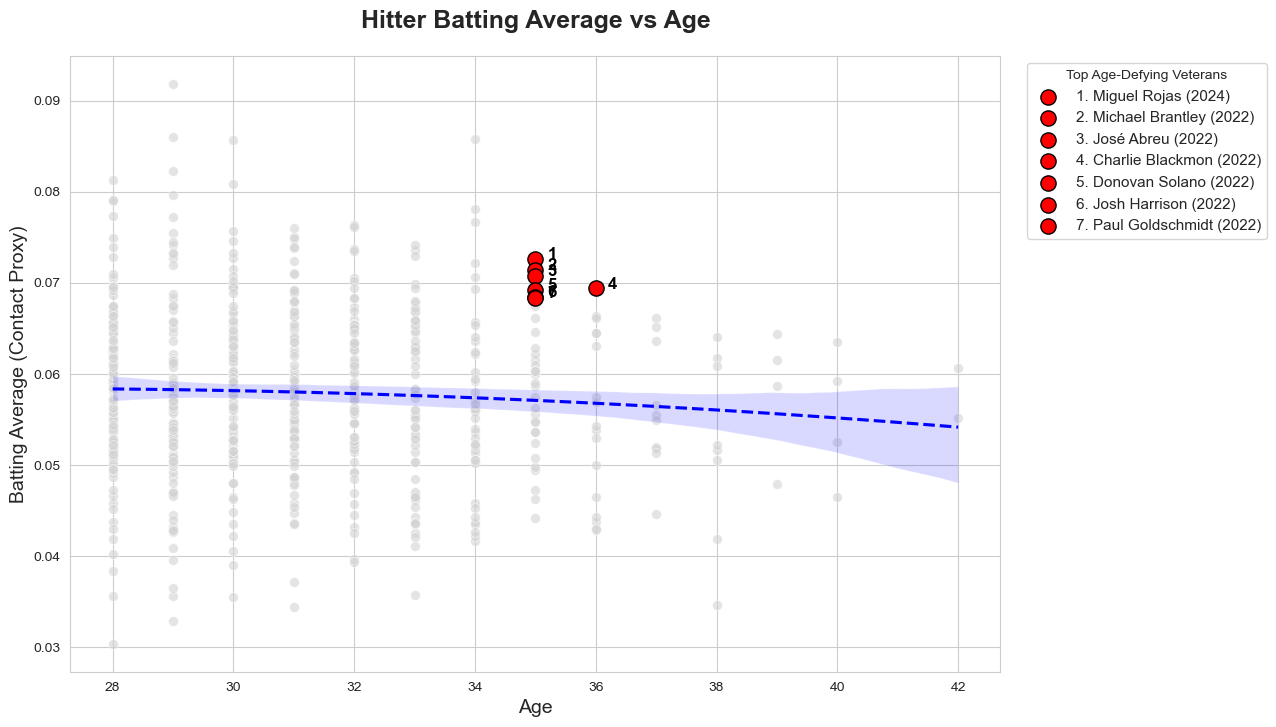

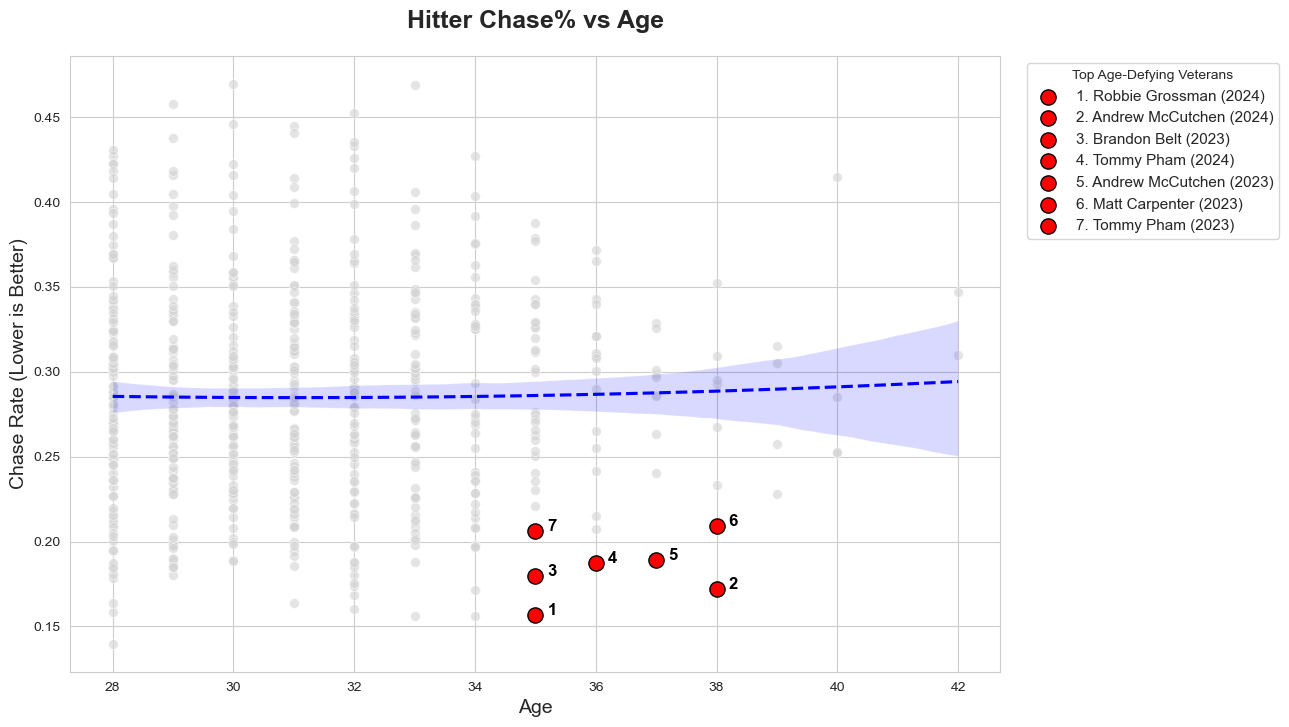


🎯 [복사해서 03번 파일에 넣을 명단]
target_pitchers_names = ['Charlie Morton', 'Jake Diekman', 'Daniel Hudson', 'Matt Bush', 'Ian Kennedy', 'Joe Kelly', 'Kirby Yates', 'Luis García', 'Blake Treinen', 'Carlos Carrasco', 'Corey Kluber', 'Lucas Luetge', 'Mike Minor', 'Ryan Brasier', 'Collin McHugh', 'Aroldis Chapman', 'Justin Verlander', 'Sonny Gray', 'Ryan Pressly', 'Huascar Brazobán', 'Justin Wilson', 'Chris Martin', 'Max Scherzer', 'Anthony Bass', 'Chris Sale', 'Brooks Raley', 'Johnny Cueto', 'Daniel Bard', 'Lance Lynn']
target_hitters_names = ['Robbie Grossman', 'Brandon Belt', 'AJ Pollock', 'Paul Goldschmidt', 'José Abreu', 'Albert Pujols', 'Donovan Solano', 'Michael Brantley', 'Andrew McCutchen', 'Miguel Cabrera', 'DJ LeMahieu', 'Mark Canha', 'Tommy Pham', 'Giancarlo Stanton', 'Yasmani Grandal', 'Miguel Rojas', 'Evan Longoria', 'Josh Harrison', 'Yan Gomes', 'Joey Votto', 'J.D. Martinez', 'David Peralta', 'Charlie Blackmon', 'Carlos Santana', 'Matt Carpenter']

📈 Generating All 6 Visualizations.

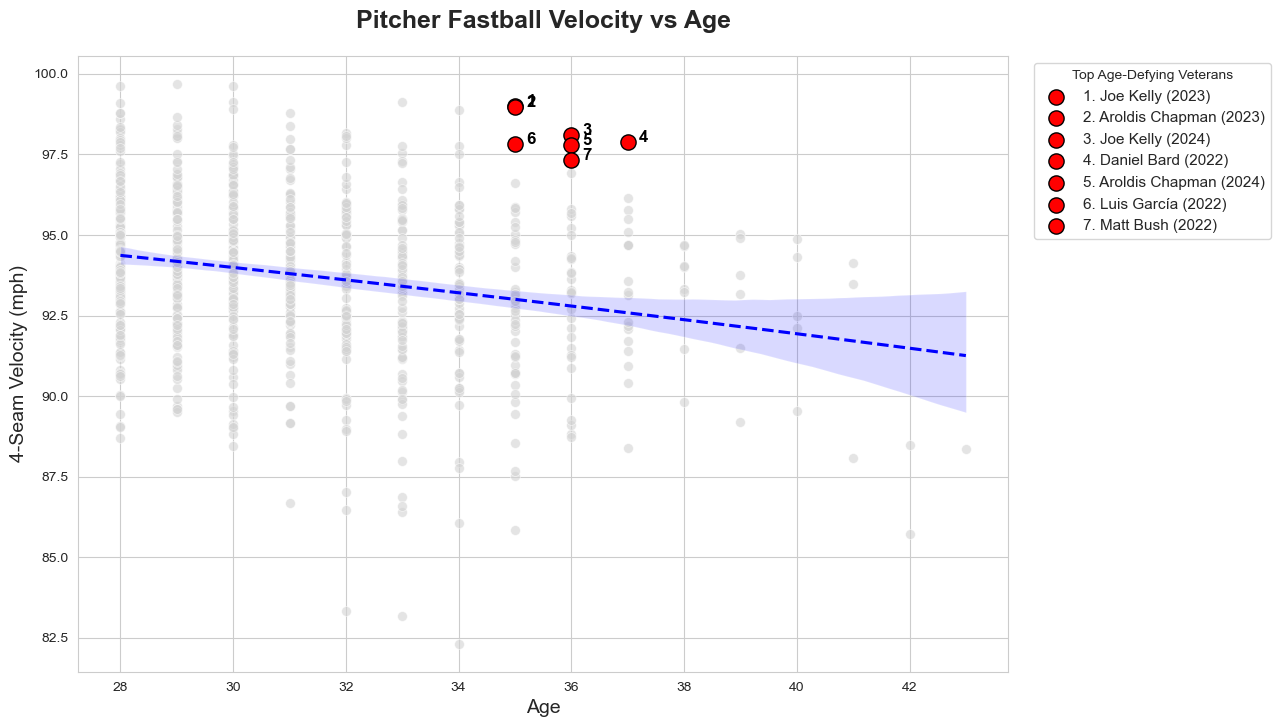

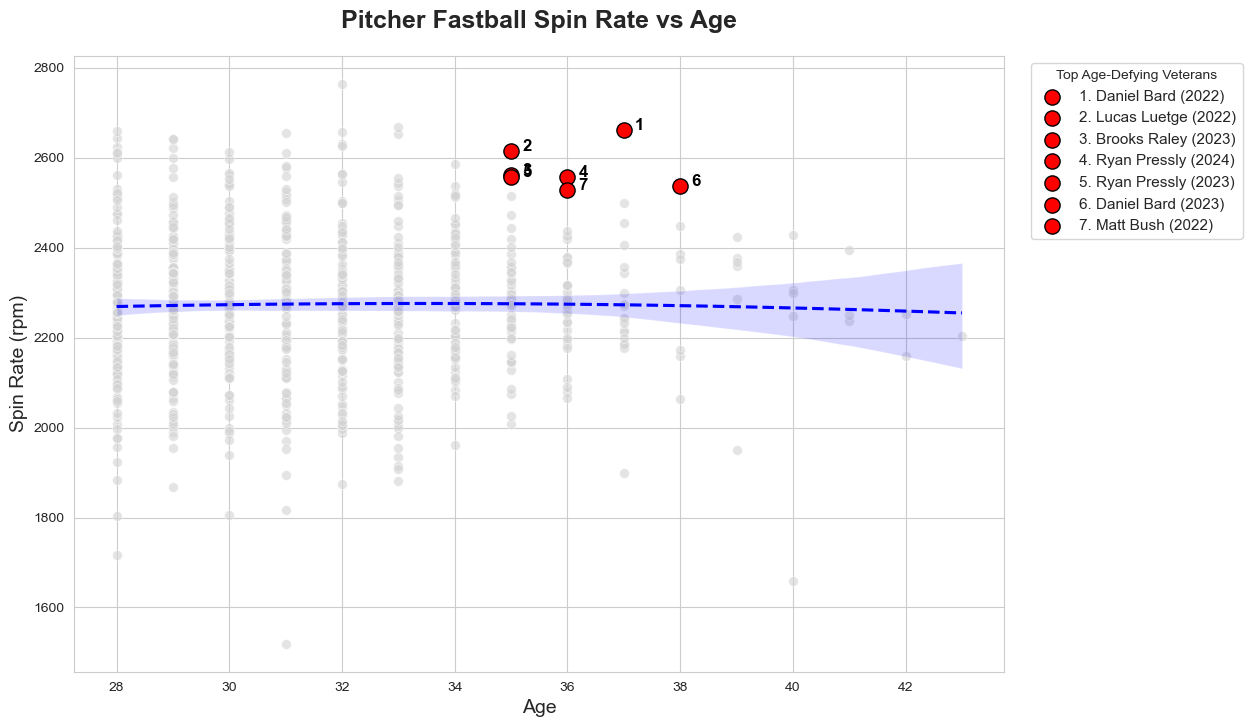

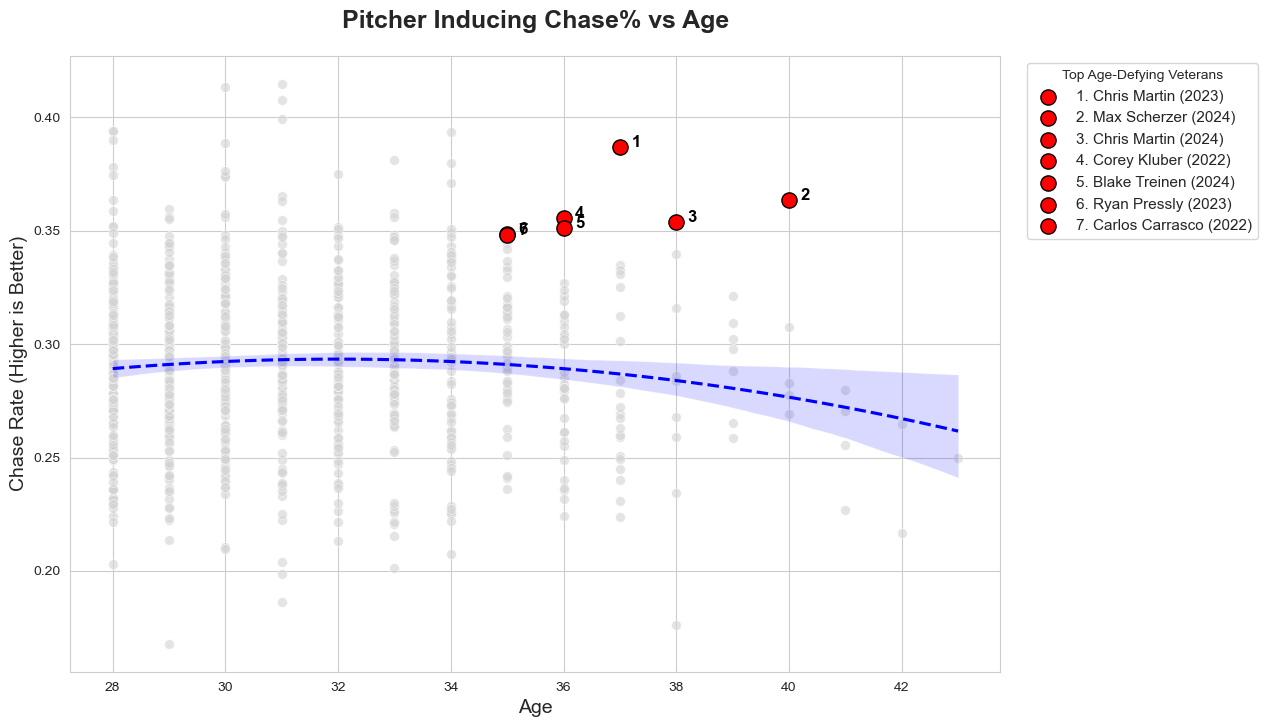

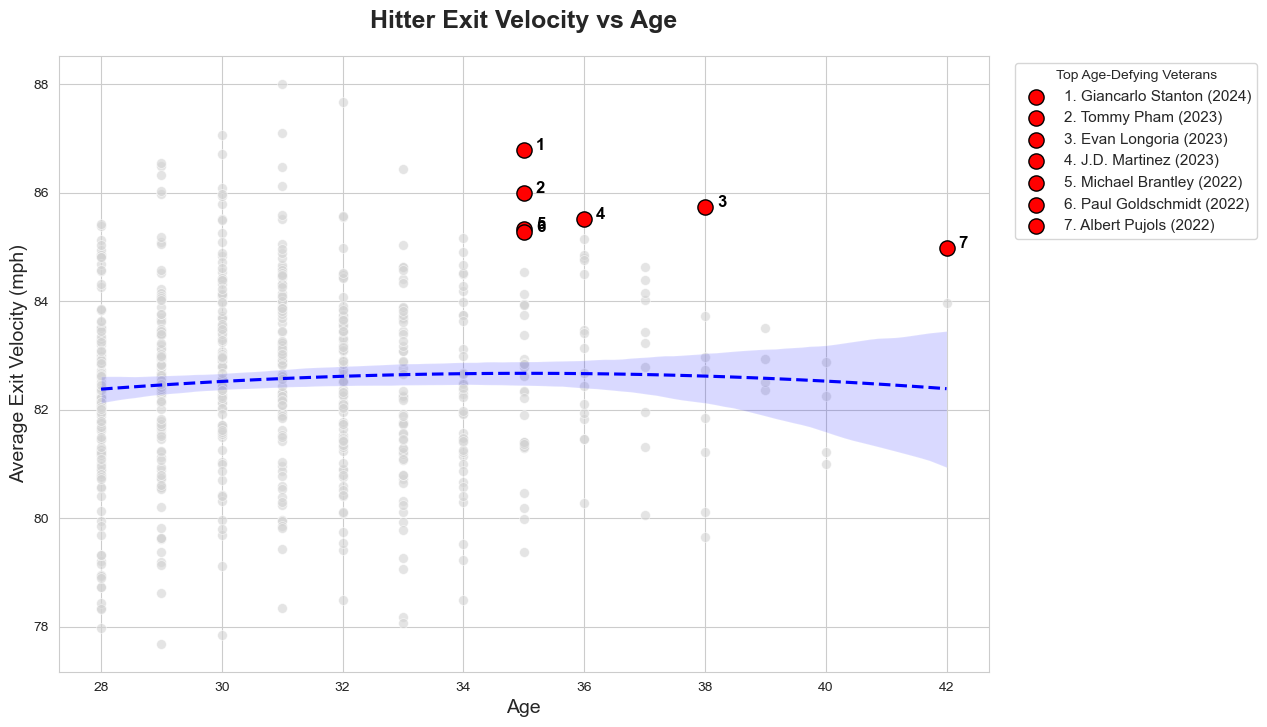

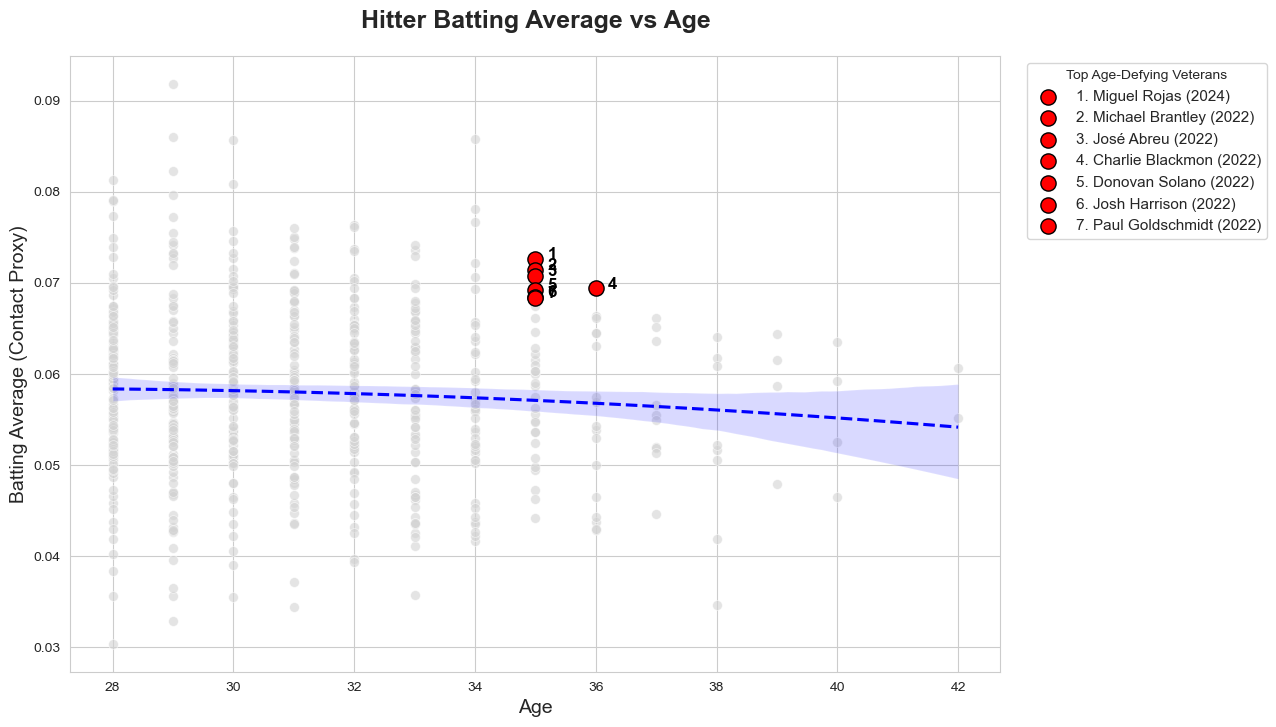

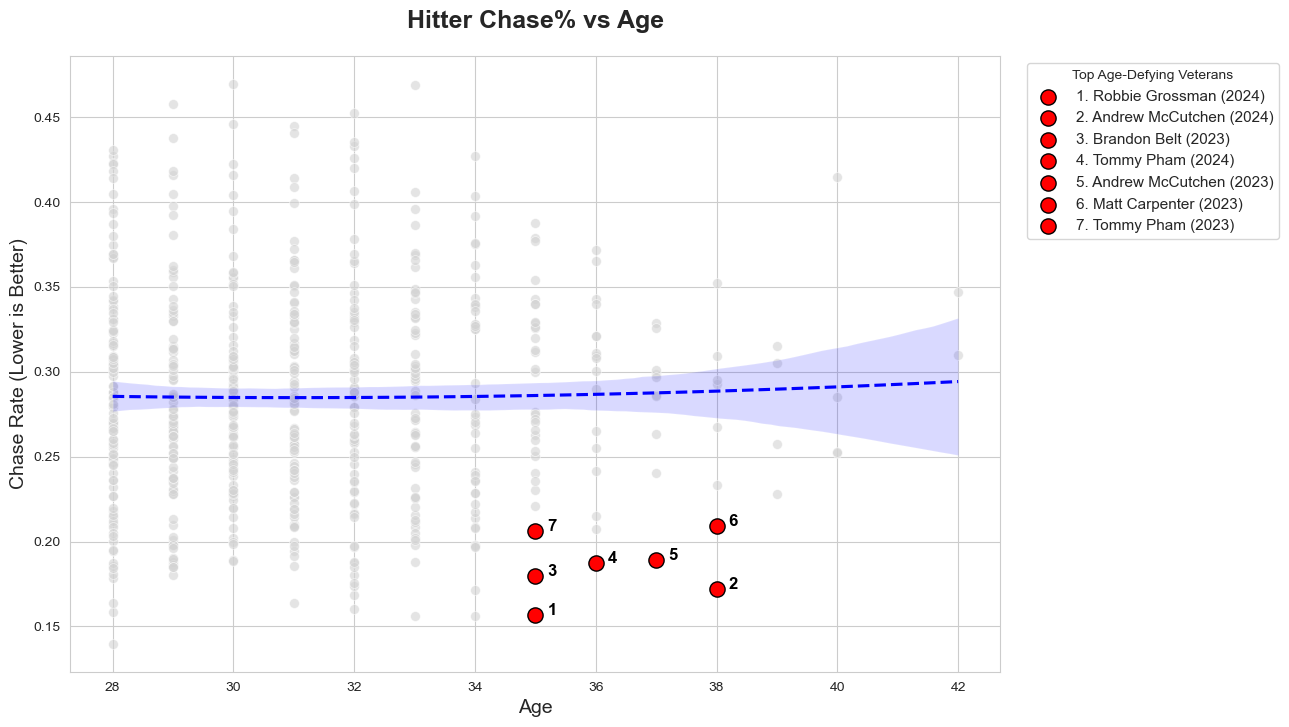

['Robbie Grossman',
 'Andrew McCutchen',
 'Brandon Belt',
 'Tommy Pham',
 'Andrew McCutchen',
 'Matt Carpenter',
 'Tommy Pham',
 'Andrew McCutchen',
 'Carlos Santana',
 'Michael Brantley',
 'Joey Votto',
 'DJ LeMahieu',
 'Carlos Santana',
 'Mark Canha',
 'Carlos Santana']

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import os
import warnings

warnings.filterwarnings('ignore')

# 1. Directory Setup & Load Data
base_dir = os.path.dirname(os.getcwd())
data_dir = os.path.join(base_dir, 'data', 'aging_project')
image_dir = os.path.join(base_dir, 'images')
os.makedirs(image_dir, exist_ok=True)

df_hitter = pd.read_csv(os.path.join(data_dir, 'aging_hitters_master.csv'))
df_pitcher = pd.read_csv(os.path.join(data_dir, 'aging_pitchers_master.csv'))

# ---------------------------------------------------------
# 2. Core Regression & Residual Function
# ---------------------------------------------------------

def calculate_aging_residuals(df, target_metric, age_col='age', metric_name="Metric"):
    # 결측치 제거 및 28세 이상 베테랑 필터링
    temp_df = df.dropna(subset=[target_metric, age_col]).copy()
    temp_df = temp_df[temp_df[age_col] >= 28] 
    
    X = temp_df[[age_col]].values
    y = temp_df[target_metric].values
    
    # 2차 다항식 변환 (y = ax^2 + bx + c)
    poly = PolynomialFeatures(degree=2)
    X_poly = poly.fit_transform(X)
    
    model = LinearRegression()
    model.fit(X_poly, y)
    
    y_pred = model.predict(X_poly)
    temp_df[f'expected_{target_metric}'] = y_pred
    temp_df[f'residual_{target_metric}'] = temp_df[target_metric] - y_pred
    
    # 통계량 출력
    r_squared = model.score(X_poly, y)
    n = len(y)
    p = 2
    se = np.sqrt(np.sum((y - y_pred)**2) / (n - p - 1))
    
    print(f"\n[{metric_name} Regression Stats]")
    print(f"  * Equation: y = {model.coef_[2]:.4f}x^2 + {model.coef_[1]:.4f}x + {model.intercept_:.4f}")
    print(f"  * R-squared: {r_squared:.4f}")
    print(f"  * Standard Error: {se:.4f}")
    print(f"  * Sample Size (N): {n}")
    
    return temp_df

# ---------------------------------------------------------
# 3. Apply Regression to All 6 Key Metrics
# ---------------------------------------------------------
print("📊 Running All 6 Regression Models...")

# --- PITCHERS ---
pitcher_velo_df = calculate_aging_residuals(df_pitcher, 'fb_velocity', metric_name="Pitcher Fastball Velocity")
pitcher_spin_df = calculate_aging_residuals(df_pitcher, 'spin_rate', metric_name="Pitcher Fastball Spin Rate")
pitcher_chase_df = calculate_aging_residuals(df_pitcher, 'chase_pct', metric_name="Pitcher Chase Rate (Induction)")

# --- HITTERS ---
hitter_ev_df = calculate_aging_residuals(df_hitter, 'avg_ev', metric_name="Hitter Exit Velocity")
hitter_avg_df = calculate_aging_residuals(df_hitter, 'avg', metric_name="Hitter Batting Average (Contact)")
hitter_chase_df = calculate_aging_residuals(df_hitter, 'chase_pct', metric_name="Hitter Chase Rate (Discipline)")

# ---------------------------------------------------------
# 4. Visualization Function (수정됨)
# ---------------------------------------------------------
def plot_aging_curve(df, target_metric, title, ylabel, ascending=False):
    plt.figure(figsize=(12, 8), facecolor='white')
    sns.set_style("whitegrid")
    
    sns.scatterplot(data=df, x='age', y=target_metric, color='lightgray', alpha=0.6, s=50)
    sns.regplot(data=df, x='age', y=target_metric, scatter=False, order=2, color='blue', line_kws={'linestyle':'--'})
    
    veteran_df = df[df['age'] >= 35]
    
    # 📍 핵심 1: 7명 -> 15명으로 넉넉하게 예비 명단 추출 (결측치 대비)
    top_outliers = veteran_df.sort_values(by=f'residual_{target_metric}', ascending=ascending).head(15)    
    
    # 그래프에는 덜 지저분하게 상위 7명만 라벨링 (선택 사항)
    for i, (_, row) in enumerate(top_outliers.head(7).iterrows(), 1):
        season_int = int(row['season'])
        label_str = f"{i}. {row['full_name']} ({season_int})"
        
        plt.scatter(row['age'], row[target_metric], color='red', s=120, edgecolor='black', zorder=5, label=label_str)
        plt.text(row['age'] + 0.2, row[target_metric], str(i), fontsize=12, weight='bold', color='black')
                 
    plt.title(title, fontsize=18, pad=20, weight='bold')
    plt.xlabel('Age', fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.legend(title="Top Age-Defying Veterans", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11)
    
    filename = title.replace(' ', '_').replace('%', 'pct').replace('(', '').replace(')', '').lower() + '.png'
    plt.savefig(os.path.join(image_dir, filename), dpi=300, bbox_inches='tight')
    plt.show()
    
    # 15명 명단 전체 반환
    return top_outliers['full_name'].tolist()

# ---------------------------------------------------------
# 5. Generate Plots & Extract Dictionaries
# ---------------------------------------------------------
print("\n📈 Generating All 6 Visualizations and Extracting Targets...")

p_velo_names = plot_aging_curve(pitcher_velo_df, 'fb_velocity', 'Pitcher Fastball Velocity vs Age', '4-Seam Velocity (mph)', ascending=False)
p_spin_names = plot_aging_curve(pitcher_spin_df, 'spin_rate', 'Pitcher Fastball Spin Rate vs Age', 'Spin Rate (rpm)', ascending=False)
p_chase_names = plot_aging_curve(pitcher_chase_df, 'chase_pct', 'Pitcher Inducing Chase% vs Age', 'Chase Rate (Higher is Better)', ascending=False)

h_ev_names = plot_aging_curve(hitter_ev_df, 'avg_ev', 'Hitter Exit Velocity vs Age', 'Average Exit Velocity (mph)', ascending=False)
h_avg_names = plot_aging_curve(hitter_avg_df, 'avg', 'Hitter Batting Average vs Age', 'Batting Average (Contact Proxy)', ascending=False)
h_chase_names = plot_aging_curve(hitter_chase_df, 'chase_pct', 'Hitter Chase% vs Age', 'Chase Rate (Lower is Better)', ascending=True)

# 📍 핵심 2: 03번 코드에 바로 복붙할 수 있게 딕셔너리 형태로 예쁘게 출력
print("\n" + "="*60)
print("🎯 [복사해서 03번 파일에 넣을 딕셔너리]")
print("target_hitters_dict = {")
for name in h_ev_names: print(f"    '{name}': 'Exit Velocity',")
for name in h_chase_names: print(f"    '{name}': 'Chase% (Discipline)',")
for name in h_avg_names: print(f"    '{name}': 'Batting Average',")
print("}\n")

print("target_pitchers_dict = {")
for name in p_velo_names: print(f"    '{name}': 'Fastball Velocity',")
for name in p_spin_names: print(f"    '{name}': 'Fastball Spin Rate',")
for name in p_chase_names: print(f"    '{name}': 'Chase% (Induction)',")
print("}")
print("="*60)# ---------------------------------------------------------
# 5. Generate Plots & Extract Names
# ---------------------------------------------------------
print("\n📈 Generating All 6 Visualizations and Extracting Targets...")

p_velo_names = plot_aging_curve(pitcher_velo_df, 'fb_velocity', 'Pitcher Fastball Velocity vs Age', '4-Seam Velocity (mph)', ascending=False)
p_spin_names = plot_aging_curve(pitcher_spin_df, 'spin_rate', 'Pitcher Fastball Spin Rate vs Age', 'Spin Rate (rpm)', ascending=False)
p_chase_names = plot_aging_curve(pitcher_chase_df, 'chase_pct', 'Pitcher Inducing Chase% vs Age', 'Chase Rate (Higher is Better)', ascending=False)

h_ev_names = plot_aging_curve(hitter_ev_df, 'avg_ev', 'Hitter Exit Velocity vs Age', 'Average Exit Velocity (mph)', ascending=False)
h_avg_names = plot_aging_curve(hitter_avg_df, 'avg', 'Hitter Batting Average vs Age', 'Batting Average (Contact Proxy)', ascending=False)
h_chase_names = plot_aging_curve(hitter_chase_df, 'chase_pct', 'Hitter Chase% vs Age', 'Chase Rate (Lower is Better)', ascending=True)

# 중복 제거 (여러 지표에서 동시에 탑을 찍은 선수들 병합)
target_pitchers = list(set(p_velo_names + p_spin_names + p_chase_names))
target_hitters = list(set(h_ev_names + h_avg_names + h_chase_names))

print("\n" + "="*50)
print("🎯 [복사해서 03번 파일에 넣을 명단]")
print("target_pitchers_names =", target_pitchers)
print("target_hitters_names =", target_hitters)
print("="*50)
# ---------------------------------------------------------
# 5. Generate All 6 Plots
# ---------------------------------------------------------
print("\n📈 Generating All 6 Visualizations...")

# 투수 3종 세트 (전부 높을수록 좋음 -> ascending=False)
plot_aging_curve(pitcher_velo_df, 'fb_velocity', 'Pitcher Fastball Velocity vs Age', '4-Seam Velocity (mph)', ascending=False)
plot_aging_curve(pitcher_spin_df, 'spin_rate', 'Pitcher Fastball Spin Rate vs Age', 'Spin Rate (rpm)', ascending=False)
plot_aging_curve(pitcher_chase_df, 'chase_pct', 'Pitcher Inducing Chase% vs Age', 'Chase Rate (Higher is Better)', ascending=False)

# 타자 3종 세트 (EV와 AVG는 높을수록 좋지만, Chase%는 낮을수록 좋음!)
plot_aging_curve(hitter_ev_df, 'avg_ev', 'Hitter Exit Velocity vs Age', 'Average Exit Velocity (mph)', ascending=False)
plot_aging_curve(hitter_avg_df, 'avg', 'Hitter Batting Average vs Age', 'Batting Average (Contact Proxy)', ascending=False)

# 📍 타자 Chase%는 '낮을수록' 좋은 선구안이므로 잔차가 마이너스인 선수(ascending=True)를 뽑습니다!
plot_aging_curve(hitter_chase_df, 'chase_pct', 'Hitter Chase% vs Age', 'Chase Rate (Lower is Better)', ascending=True)